# Raw-to-result tutorial 2 — annotated lung Ccn1

This notebook reads the downloaded M002 raw RNA/guide H5 axes together with the
official cell-type and clone CSVs. It calls Ccn1 guide-positive non-immune source
components and quantifies macrophage composition around their boundaries.
No precomputed PerturbRadius table is loaded.

In [1]:
from pathlib import Path
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

REPO = Path.cwd()
if not (REPO / "pyproject.toml").exists(): REPO = REPO.parent
sys.path.insert(0, str(REPO / "src"))
DATA_ROOT = Path(os.environ.get("PERTURBRADIUS_DATA_ROOT", "/home/dataset-local/hulei/SpDiff/data"))
RAW = DATA_ROOT / "SPAC_anno" / "extracted"
import perturbradius as pr
plt.rcParams.update({"font.size": 13, "axes.grid": False, "lines.linewidth": 1.7,
                     "figure.dpi": 120, "font.family": "DejaVu Sans"})

rna_path = RAW / "Transcriptome/Lung_Metastasis_M002/994_filtered_gene_bc_matrix.h5"
guide_path = RAW / "Perturbation/Lung_Metastasis_M002/994_filtered_guide_bc_matrix.h5"
annotation_path = RAW / "Annotation/Lung_Metastasis_M002/lm994_cell_annotated.csv"
clone_path = RAW / "Clone/Lung_Metastasis_M002/lm994_clone_annotated.csv"
for path in [rna_path, guide_path, annotation_path, clone_path]: assert path.exists(), path
print("Raw annotated cohort:", RAW)
display(pr.h5_schema(guide_path).query("dataset in ['X/data','X/indptr','obs/_index','var/_index','obsm/spatial']"))

Raw annotated cohort: /home/dataset-local/hulei/SpDiff/data/SPAC_anno/extracted


,dataset,shape,dtype
0,X/data,37374,float32
2,X/indptr,358150,int32
3,obs/_index,358149,object
7,obsm/spatial,358149 × 3,uint32
8,var/_index,1520,object


In [2]:
axes = pr.read_h5_axes(rna_path)
calls = pr.read_sparse_guide_calls(guide_path)
annotation = pd.read_csv(annotation_path).rename(columns={"index": "barcode"})
official = pd.read_csv(clone_path).rename(columns={"index": "barcode", "clone": "official_clone"})
frame = (axes.merge(calls, on="barcode", validate="one_to_one")
         .merge(annotation, on="barcode", how="left", validate="one_to_one")
         .merge(official, on="barcode", how="left", validate="one_to_one"))
frame["section"] = "lm994"
frame["x_um"], frame["y_um"] = frame.array_col * 8.0, frame.array_row * 8.0
frame["target_gene"] = frame.target_gene.fillna("")
frame["guide"] = frame.top_guide.fillna("")
frame["is_ntc"] = frame.is_ntc.astype(bool)
frame["is_source"] = ((frame.guide_total >= 2) & (frame.top_fraction >= .70)
                      & frame.cell_type.eq("Non-immune cell"))
# Missing official annotation remains unavailable, never a false macrophage.
frame["response"] = np.where(frame.cell_type.notna(), frame.cell_type.eq("Macrophage"), np.nan)
data = pr.validate_data(frame)
display(frame.cell_type.value_counts(dropna=False).rename("bins").to_frame())
print("High-confidence non-immune Ccn1 source bins:", int((frame.is_source & frame.target_gene.eq('Ccn1')).sum()))

,bins
cell_type,
NaN,163793
Non-immune cell,154369
Macrophage,11501
Neutrophil,8087
T,8050
DC,5885
Mast,2393
NK,2108
B,1963


High-confidence non-immune Ccn1 source bins: 950


In [3]:
components = pr.call_components(data, perturbation="Ccn1", eps_um=24,
                                min_samples=8, min_source_bins=15)
rings = pr.build_distance_rings(data, components, ring_edges=(0,20,40,80,120,200),
                                bin_size_um=8, exclude_all_sources=True)
source = components.membership.merge(data[["_row_id","x_um","y_um","section"]], on="_row_id")
display(components.summary)

,component_id,section,target_gene,guide,is_ntc,n_source_bins,centroid_x_um,centroid_y_um
0,C0001,lm994,Ccn1,sgCcn1_2,False,537,1040.566108,3177.459963
1,C0002,lm994,Ccn1,sgCcn1_2,False,28,1204.571429,3018.571429
2,C0003,lm994,Ccn1,sgCcn1_2,False,217,1208.958525,3437.161290
3,C0004,lm994,Ccn1,sgCcn1_2,False,18,1254.222222,3296.888889


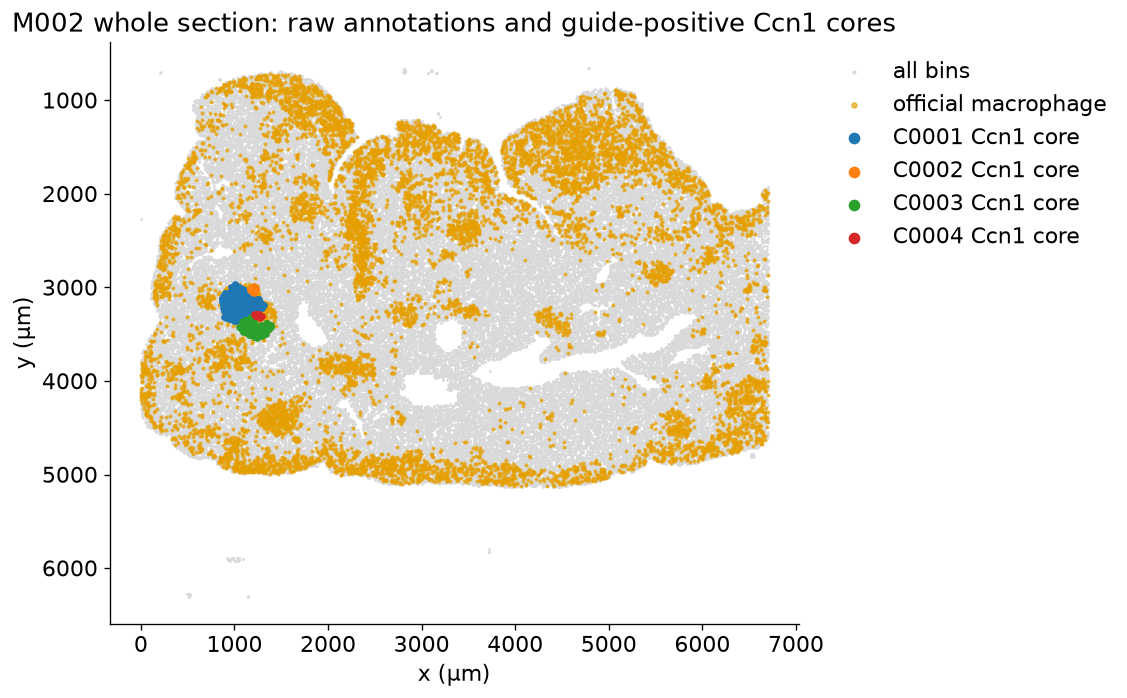

In [4]:
# Whole-section audit: all tissue bins, official macrophage labels and raw Ccn1 source cores.
fig, ax = plt.subplots(figsize=(9, 7))
background = data.iloc[::5]
ax.scatter(background.x_um, background.y_um, s=.5, color="#D9D9D9", rasterized=True, label="all bins")
mac = data[data.cell_type.eq("Macrophage")]
ax.scatter(mac.x_um, mac.y_um, s=2, color="#E69F00", alpha=.65, rasterized=True, label="official macrophage")
for j, (cid, group) in enumerate(source.groupby("component_id")):
    ax.scatter(group.x_um, group.y_um, s=9, color=plt.get_cmap("tab10")(j), label=f"{cid} Ccn1 core", rasterized=True)
ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)"); ax.set_aspect("equal"); ax.invert_yaxis()
ax.set_title("M002 whole section: raw annotations and guide-positive Ccn1 cores")
ax.legend(frameon=False, bbox_to_anchor=(1.02,1), loc="upper left", markerscale=2)
ax.spines[["top","right"]].set_visible(False); fig.tight_layout(); plt.show()

In [5]:
# Unsmoothed ring fractions and effective annotation counts.
ring_stats = (rings.groupby(["component_id","ring_index","ring"], as_index=False)
              .agg(macrophage_fraction=("response","mean"), annotated_bins=("response","count")))
far = ring_stats[ring_stats.ring_index.eq(4)][["component_id","macrophage_fraction","annotated_bins"]].rename(
    columns={"macrophage_fraction":"far_fraction","annotated_bins":"far_annotated_bins"})
ring_stats = ring_stats.merge(far, on="component_id", validate="many_to_one")
ring_stats["delta"] = ring_stats.macrophage_fraction - ring_stats.far_fraction
near_far = (ring_stats[ring_stats.ring_index.isin([0,1])]
            .groupby("component_id", as_index=False).agg(near_far=("delta","mean"),
                                                         far_annotated_bins=("far_annotated_bins","first")))
near_far["evaluable"] = near_far.far_annotated_bins.ge(20)
display(near_far)

,component_id,near_far,far_annotated_bins,evaluable
0,C0001,0.096881,676,True
1,C0002,0.164207,89,True
2,C0003,0.083469,551,True
3,C0004,-0.814263,1,False


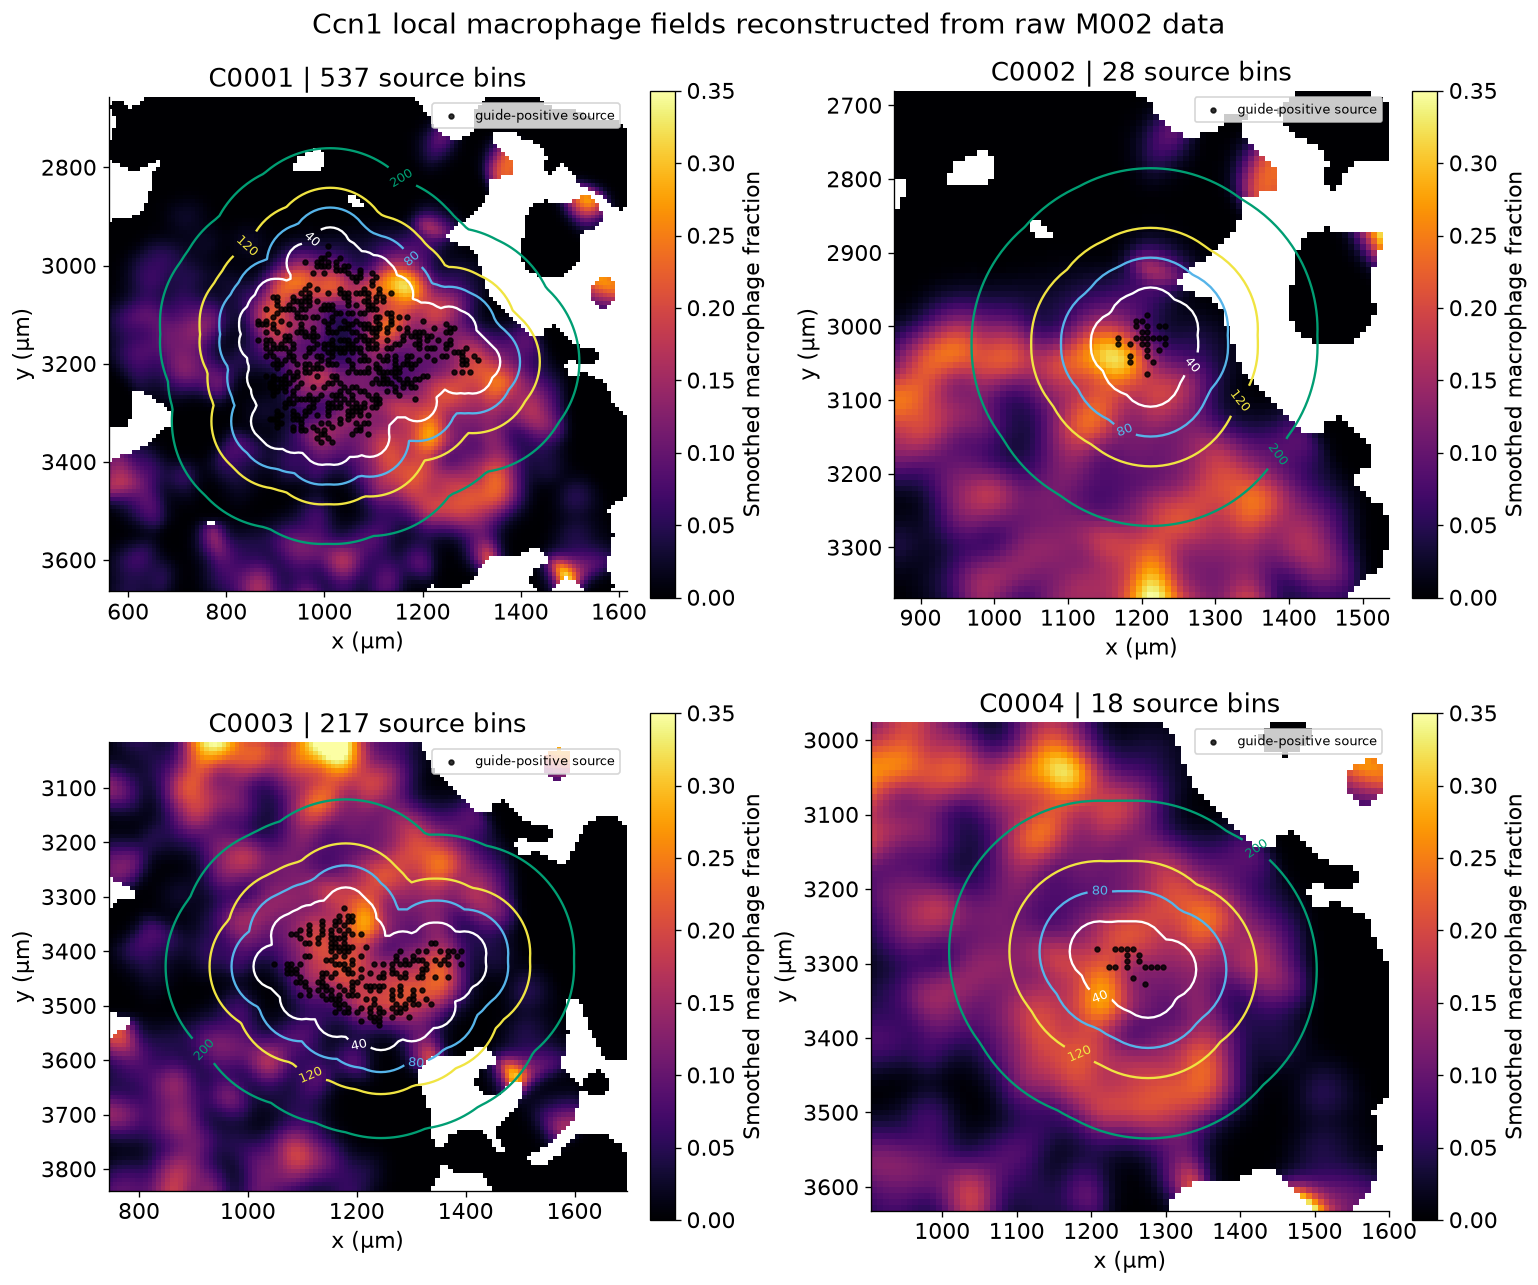

In [6]:
# One local spatial map per raw component, with the same source-core/contour grammar as the Rab8a figure.
n = len(components.summary)
fig, axes = plt.subplots(2, 2, figsize=(13, 11)); axes = axes.ravel()
for ax, row in zip(axes, components.summary.itertuples()):
    local_source = source[source.component_id.eq(row.component_id)]
    pr.plot_local_response(data, local_source, response_col="response", resolution=8,
                           pad=300, sigma_bins=3, contour_levels=(40,80,120,200),
                           ax=ax, title=f"{row.component_id} | {row.n_source_bins} source bins",
                           cbar_label="Smoothed macrophage fraction", cmap="inferno", value_limits=(0,.35))
fig.suptitle("Ccn1 local macrophage fields reconstructed from raw M002 data", fontsize=17)
fig.tight_layout(); plt.show()

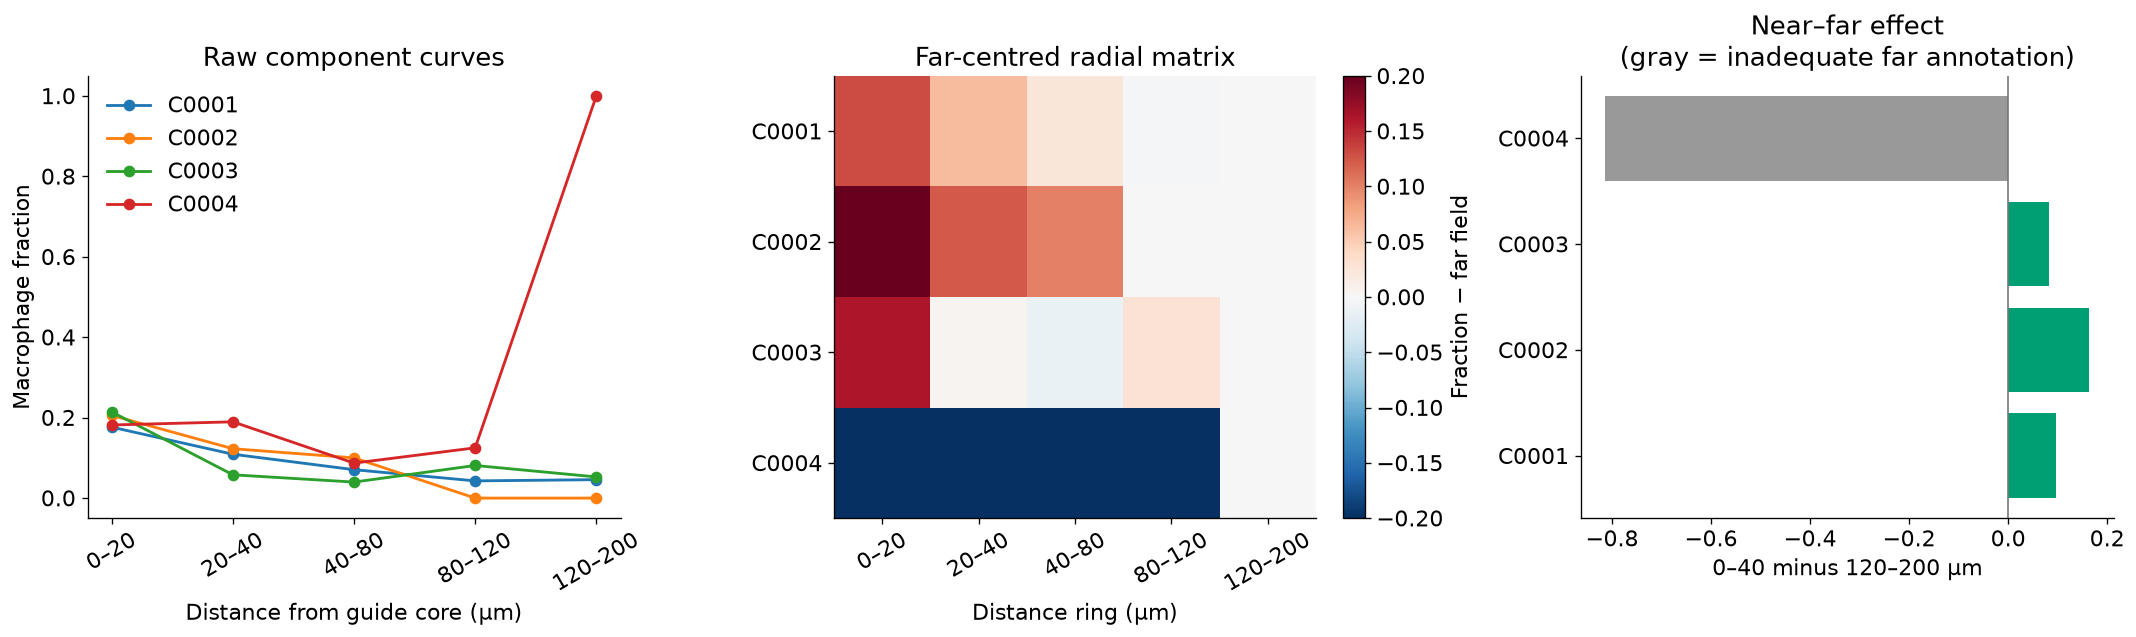

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for cid, group in ring_stats.groupby("component_id"):
    axes[0].plot(group.ring_index, group.macrophage_fraction, marker="o", label=cid)
axes[0].set_xticks(range(5), ["0–20","20–40","40–80","80–120","120–200"], rotation=30)
axes[0].set_xlabel("Distance from guide core (µm)"); axes[0].set_ylabel("Macrophage fraction")
axes[0].set_title("Raw component curves"); axes[0].legend(frameon=False)
matrix = ring_stats.pivot(index="component_id", columns="ring_index", values="delta").reindex(columns=range(5))
im = axes[1].imshow(matrix, aspect="auto", cmap="RdBu_r", vmin=-.2, vmax=.2)
axes[1].set_xticks(range(5), ["0–20","20–40","40–80","80–120","120–200"], rotation=30)
axes[1].set_yticks(range(len(matrix)), matrix.index); axes[1].set_title("Far-centred radial matrix")
axes[1].set_xlabel("Distance ring (µm)"); plt.colorbar(im, ax=axes[1], fraction=.046, label="Fraction − far field")
colors = np.where(near_far.evaluable, "#009E73", "#999999")
axes[2].barh(near_far.component_id, near_far.near_far, color=colors)
axes[2].axvline(0,color="#777",lw=1); axes[2].set_xlabel("0–40 minus 120–200 µm")
axes[2].set_title("Near–far effect\n(gray = inadequate far annotation)")
for ax in axes: ax.spines[["top","right"]].set_visible(False)
fig.tight_layout(); plt.show()

In [8]:
valid = near_far[near_far.evaluable]
display(Markdown(f"""
### Interpretation

The raw guide matrix produces **{len(components.summary)} Ccn1 source cores**. Among the
**{len(valid)} components with at least 20 annotated far-field bins**, macrophage fraction is
higher at 0–40 µm in **{int((valid.near_far>0).sum())}/{len(valid)}**. One small component is
not allowed to drive the claim because its 120–200 µm reference is annotation-poor.

Thus the defensible result is a **Ccn1-associated near-field macrophage enrichment in M002**.
It is stronger and spatially clearer than the Rab8a state pattern, but it still comes from one
section and one dominant guide; it is not an independently replicated causal propagation radius.
"""))


### Interpretation

The raw guide matrix produces **4 Ccn1 source cores**. Among the
**3 components with at least 20 annotated far-field bins**, macrophage fraction is
higher at 0–40 µm in **3/3**. One small component is
not allowed to drive the claim because its 120–200 µm reference is annotation-poor.

Thus the defensible result is a **Ccn1-associated near-field macrophage enrichment in M002**.
It is stronger and spatially clearer than the Rab8a state pattern, but it still comes from one
section and one dominant guide; it is not an independently replicated causal propagation radius.
